# FRED Foreign Block

World interest rates, a world price level and world commodity prices, read from the St. Louis Fed's
FRED API through `kuznets`. The small open economy model treats these as exogenous, so the same six
series serve whichever country is being estimated.

## Provenance

These are the fields of the `FRED` declaration in `climate_risk/data/fred.py`. It is an `ApiSource`,
so it carries an endpoint rather than a filename. Read the license row before redistributing
anything: it is the only source here whose terms depend on which rows you read.

In [1]:
import dataclasses

from IPython.display import Markdown

from climate_risk.data.fred import FRED

declared = {"publisher": "Federal Reserve Bank of St. Louis"} | dataclasses.asdict(FRED)
rows = [f"| {field} | {value} |" for field, value in declared.items()]

Markdown("\n".join(["| Field | Value |", "|---|---|", *rows]))

| Field | Value |
|---|---|
| publisher | Federal Reserve Bank of St. Louis |
| url | https://api.stlouisfed.org/fred/series/observations |
| license | Series carry the terms of whoever published them. The US federal series read here are public domain; other series on FRED are redistributed under restrictions, some serving only a rolling window of history. |
| citation | Federal Reserve Bank of St. Louis, FRED (Federal Reserve Economic Data), https://fred.stlouisfed.org/. |
| retrieved | 2026-09-05 |

## Loading it

One request per series, stacked into a single frame. The cache directory is your choice, and this
page uses one named `data` in the working directory.

In [2]:
import logging

from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

from climate_risk.data.fred import load_fred_data
from climate_risk.plotting import PALETTE, configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [3]:
cache_dir = Path("data")

foreign = load_fred_data(cache_dir)

## What you get

A polars frame in long form: `series`, `date`, `value`. Long rather than wide because the series
carry different frequencies, and a wide frame would be mostly null.

In [4]:
foreign.head()

series,date,value
str,date,f64
"""commodity_all""",1992-01-01,48.054885
"""commodity_all""",1992-02-01,48.009238
"""commodity_all""",1992-03-01,47.720182
"""commodity_all""",1992-04-01,48.520716
"""commodity_all""",1992-05-01,49.766031


## Units

| Column | Unit |
|---|---|
| `series` | the name the loader stores the FRED series ID under |
| `date` | observation date, at the series' own frequency |
| `value` | depends on the series |

`value` is one column carrying several units, which is what makes a `describe` over the stacked
frame meaningless:

| Series | Unit |
|---|---|
| `world_rate_3m` | percent per year |
| `world_rate_10y` | percent per year |
| `world_price_level` | index |
| `commodity_all` | index |
| `commodity_energy` | index |
| `commodity_food` | index |

None of the index bases survive into the cache. An index cannot be rescaled or spliced onto another
series without its base period, so read it off FRED before doing either.

## Coverage

`describe` needs the frame pivoted wide, because one stacked column of values mixes percent rates
with index levels. Each series then gets its own column and its own units, and the null counts are
the frequency mismatch made visible: a monthly series is absent on every day a daily one reports.

In [5]:
# Pivoted wide first, so each series is described in its own units rather than stacked into one.
foreign.pivot(on="series", index="date", values="value").drop("date").describe()

statistic,commodity_all,commodity_energy,commodity_food,world_price_level,world_rate_10y,world_rate_3m
str,f64,f64,f64,f64,f64,f64
"""count""",415.0,415.0,415.0,954.0,16154.0,18160.0
"""null_count""",18141.0,18141.0,18141.0,17602.0,2402.0,396.0
"""mean""",110.981586,130.357456,93.17032,125.367268,5.805399,4.188853
"""std""",50.963288,72.067089,28.04106,90.626711,2.929343,3.043689
"""min""",42.15361,30.836014,55.136311,21.48,0.52,-0.05
"""25%""",57.701586,62.239226,64.474131,32.88,3.9,1.88
"""50%""",111.041894,125.73246,96.295731,110.2,5.4,4.1
"""75%""",161.300216,177.429948,119.25003,202.0,7.53,5.65
"""max""",241.934979,376.412083,165.829547,333.979,15.84,17.14


In [6]:
foreign.group_by("series").agg(
    pl.len().alias("observations"),
    pl.col("date").min().alias("first"),
    pl.col("date").max().alias("last"),
).sort("series")

series,observations,first,last
str,u32,date,date
"""commodity_all""",415,1992-01-01,2026-07-01
"""commodity_energy""",415,1992-01-01,2026-07-01
"""commodity_food""",415,1992-01-01,2026-07-01
"""world_price_level""",954,1947-01-01,2026-07-01
"""world_rate_10y""",16154,1962-01-02,2026-09-03
"""world_rate_3m""",18160,1954-01-04,2026-09-03


## A plot

World inflation against the long rate. Inflation is the year-over-year change in the price level,
which FRED publishes monthly, while the rate is daily, so this one figure shows the frequency
mismatch the frame carries. The gap between the two is what a real rate is built from.

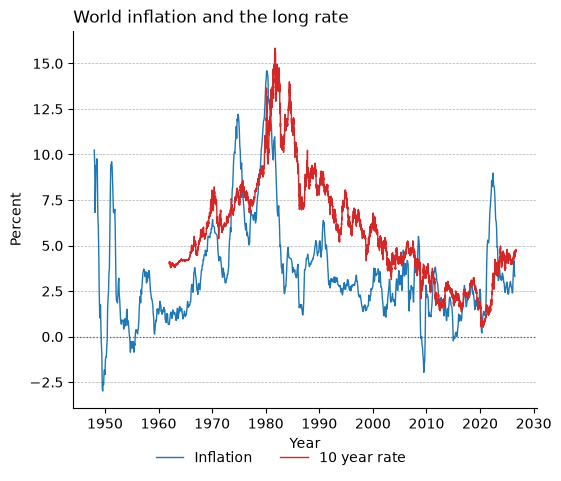

In [7]:
prices = foreign.filter(pl.col("series") == "world_price_level").select("date", "value")

# Year-over-year by an explicit date join rather than a row offset, so a month FRED never published
# leaves a hole instead of a comparison spanning thirteen months.
a_year_on = prices.with_columns(pl.col("date").dt.offset_by("12mo")).rename({"value": "year_earlier"})
inflation = prices.join(a_year_on, on="date", how="inner").with_columns(
    (100 * (pl.col("value") / pl.col("year_earlier") - 1)).alias("value")
)

long_rate = foreign.filter(pl.col("series") == "world_rate_10y")

figure, axis = plt.subplots(figsize=(5.5, 4.5))
axis.plot(inflation["date"], inflation["value"], color=PALETTE["primary"], label="Inflation", lw=1.0)
axis.plot(long_rate["date"], long_rate["value"], color=PALETTE["secondary"], label="10 year rate", lw=1.0)
axis.axhline(0.0, color=PALETTE["divider"], ls=":", lw=0.9)
axis.set_title("World inflation and the long rate", loc="left")
axis.set_xlabel("Year")
axis.set_ylabel("Percent")

handles, labels = axis.get_legend_handles_labels()
figure.legend(
    handles=handles,
    labels=labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=len(labels),
    frameon=False,
)

plt.show()

## Gotchas

*The license is per series, not per source.* The US federal series read here are public domain.
Other series on FRED are redistributed under the terms of whoever published them, and some serve
only a rolling window of history rather than the full record. Check a series before redistributing
it, whatever the row above says about the ones already here.

*It is not exported at package level.* `climate_risk.load_wb_data` resolves and
`climate_risk.load_fred_data` does not, so this one is imported from `climate_risk.data.fred`
directly. Nothing about the two loaders explains the difference.

*Frequencies are mixed and the frame does not say so.* The 3 month rate carries daily observations
and the commodity indices carry monthly ones. Resample before joining anything to anything.

*These are world aggregates, not country series.* Nothing here is keyed by country, unlike the World
Bank panel. Joining the two means broadcasting these across countries deliberately.

*A withdrawn series returns nothing rather than failing.* FRED answers with an empty frame, so the
loader raises instead of letting a series reach the panel as absent.

*Missing observations are dropped, not zeroed.* FRED reports gaps explicitly and the loader removes
them, so a date with no row is a date with no observation.